# Predictive Modeling

## Prepare my workspace

In [208]:
# Import needed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sms
from statsmodels.stats.diagnostic import linear_reset
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import sys
# Import the related function of the utils.py file
sys.path.append("D:\Data science project\Data science\Codveda-internship\Level 2")
from Level_2.utils import *


In [209]:
# Load the data
reg_df = pd.read_csv(r"D:\Data science project\Data science\Codveda-internship\Level 1\Task 2\processed_real_estate.csv")

# preview the data
print("Real estates data:\n")
reg_df

Real estates data:



,name,sqm,year_built,Price(EGP),Price/Sqm,has_main_facilities,has_security_features,has_parking_safety,has_building_facilities,has_other_features,...,propertySubType_Office,propertySubType_Others(very rare),propertySubType_Retail,log(sqm),log(price),log(price/sqm),Is log(price/sqm) outlier,Is log(sqm) outlier,Is log(price) outlier,Is FloorNumber outlier
0,Alamain (Latin District),92.86,2025,6594000,71010.1228,1,1,0,0,1,...,0,0,0,4.531093,15.701671,11.170578,False,False,False,False
1,Beachfront Tower - B1,398.00,2025,66104000,166090.4523,0,0,0,0,1,...,0,0,0,5.986452,18.006740,12.020288,False,False,True,False
2,PODIA,93.00,2025,12824000,137892.4731,0,1,1,0,1,...,1,0,0,4.532599,16.366829,11.834229,False,False,False,True
3,Mazarine Apartment,252.00,2025,12857000,51019.8413,1,1,0,0,0,...,0,0,0,5.529429,16.369399,10.839970,False,False,False,False
4,Alamain (Latin District),209.42,2025,8721000,41643.5870,1,1,0,0,1,...,0,0,0,5.344342,15.981244,10.636903,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
851,Alamain (Latin District),177.47,2025,5678000,31994.1399,1,1,0,0,1,...,0,0,0,5.178802,15.552110,10.373308,False,False,False,False
852,Jade Park,692.00,2025,25292000,36549.1329,1,0,1,1,0,...,0,0,0,6.539586,17.045999,10.506413,False,True,False,False
853,Mamsha Avenue,171.00,2025,6137000,35888.8889,1,1,0,0,1,...,0,0,0,5.141664,15.629847,10.488183,False,False,False,False
854,Alamain (Latin District),207.58,2025,5933000,28581.7516,1,1,0,0,1,...,0,0,0,5.335517,15.596041,10.260524,False,False,False,False


## Regression

### Pick the wanted features only

In [210]:
drop_cols = ["sqm","Price(EGP)","Price/Sqm",
             "year_built","FloorNumber","BuildingNumber",
             "UnitNumber","Is FloorNumber outlier","LowFloor",
             "Bedroom_0","Bathroom_0","city_Cairo",
             "governorate_Cairo","propertyCategory_Residential",
             "propertySubType_Apartment","city_Mersa Matruh",
             "governorate_Matrouh","governorate_Alexandria","governorate_Dakahlia"] # The unnecessary columns, and first dummy from every categorical column of dummies for full rank dummies, Dropping governorate Matrouh because I have two values of Matrouh with different columns
reg_df = reg_df.drop(drop_cols, axis=1) # drop these columns

# save the data for the next tasks
reg_df.to_csv("models_data.csv",index=False)
# preview the data
reg_df

,name,has_main_facilities,has_security_features,has_parking_safety,has_building_facilities,has_other_features,HighFloor,MidFloor,has_modern,has_facilities,...,propertySubType_Attached Houses,propertySubType_Office,propertySubType_Others(very rare),propertySubType_Retail,log(sqm),log(price),log(price/sqm),Is log(price/sqm) outlier,Is log(sqm) outlier,Is log(price) outlier
0,Alamain (Latin District),1,1,0,0,1,0,1,1,1,...,0,0,0,0,4.531093,15.701671,11.170578,False,False,False
1,Beachfront Tower - B1,0,0,0,0,1,1,0,0,1,...,0,0,0,0,5.986452,18.006740,12.020288,False,False,True
2,PODIA,0,1,1,0,1,1,0,0,0,...,0,1,0,0,4.532599,16.366829,11.834229,False,False,False
3,Mazarine Apartment,1,1,0,0,0,0,1,0,1,...,0,0,0,0,5.529429,16.369399,10.839970,False,False,False
4,Alamain (Latin District),1,1,0,0,1,0,0,0,0,...,0,0,0,0,5.344342,15.981244,10.636903,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
851,Alamain (Latin District),1,1,0,0,1,0,0,0,0,...,0,0,0,0,5.178802,15.552110,10.373308,False,False,False
852,Jade Park,1,0,1,1,0,0,1,0,1,...,0,0,0,0,6.539586,17.045999,10.506413,False,True,False
853,Mamsha Avenue,1,1,0,0,1,0,1,0,1,...,0,0,0,0,5.141664,15.629847,10.488183,False,False,False
854,Alamain (Latin District),1,1,0,0,1,0,1,1,1,...,0,0,0,0,5.335517,15.596041,10.260524,False,False,False


### Non-outliers regression

In [211]:
outliers_list = ["Is log(price) outlier", "Is log(sqm) outlier"]
drop_cols = ["name","log(price)","Is log(price) outlier", "Is log(sqm) outlier","Is log(price/sqm) outlier", "log(price/sqm)"]
x,y = set_xy(reg_df, "log(price)", False, outliers_list, drop_cols) 
X_train, X_test, y_train, y_test = split_data(x,y)

x

,has_main_facilities,has_security_features,has_parking_safety,has_building_facilities,has_other_features,HighFloor,MidFloor,has_modern,has_facilities,has_green_view,...,city_New Administrative Capital,city_New Cairo,city_North Coast,city_Old Cairo,propertyCategory_Commercial,propertySubType_Attached Houses,propertySubType_Office,propertySubType_Others(very rare),propertySubType_Retail,log(sqm)
0,1,1,0,0,1,0,1,1,1,0,...,0,0,1,0,0,0,0,0,0,4.531093
2,0,1,1,0,1,1,0,0,0,1,...,0,0,0,0,1,0,1,0,0,4.532599
3,1,1,0,0,0,0,1,0,1,1,...,0,0,0,0,0,0,0,0,0,5.529429
4,1,1,0,0,1,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,5.344342
5,0,1,0,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,4.934474
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
849,1,1,0,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,0,0,4.867534
850,1,1,0,0,1,0,1,1,1,0,...,0,0,1,0,0,0,0,0,0,4.835567
851,1,1,0,0,1,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,5.178802
853,1,1,0,0,1,0,1,0,1,1,...,1,0,0,0,0,0,0,0,0,5.141664


#### Make the original model

In [212]:
reg_summary(X_train,y_train)

The regression model summary:
                         Results: Ordinary least squares
Model:                   OLS                   Adj. R-squared:          0.814    
Dependent Variable:      log(price)            AIC:                     -12.0206 
Date:                    2025-11-05 13:45      BIC:                     116.0646 
No. Observations:        612                   Log-Likelihood:          35.010   
Df Model:                28                    F-statistic:             96.40    
Df Residuals:            583                   Prob (F-statistic):      3.27e-198
R-squared:               0.822                 Scale:                   0.054818 
---------------------------------------------------------------------------------
                                   Coef.  Std.Err.    t    P>|t|   [0.025  0.975]
---------------------------------------------------------------------------------
const                             10.9402   0.3239 33.7773 0.0000 10.3041 11.5763
has_main_fa

Model overall statistically strong:
- F-statistic: 77.83, p-value: 0.00 --> At least one of them effect on log(price)
- R-squared: 0.822, Adj. R-squared: 0.793 --> The model explained 80% of the data which is good
- AIC, BIC: -49.0950, 82.0533 both looks fine
- Skew: 0.003(roughly normal), Kurtosis: 3.169(Roughly normal)
-JB: 0.695, p-value: 0.707 --> Fail to reject normality of residuals
- Condition Number: Very high value

> Solution: Center log(sqm), Drop one of city, Add the square of sqm because of non-linear relationship between them, and add some interactions

In [213]:
reg_df["log(sqm)_centered"] = reg_df["log(sqm)"] - x["log(sqm)"].mean() # center log(sqm)

reg_df["log(sqm) centered ** 2"] = reg_df["log(sqm)_centered"] ** 2 # centered log(sqm) ^2

reg_df.drop("log(sqm)",axis = 1, inplace=True) # drop log(sqm)

# HighFloor × has_green_view
reg_df["HighFloor * has_green_view"] = reg_df["HighFloor"] * reg_df["has_green_view"]
# has water features x has green view
reg_df["has_water_feature * has_green_view"] = reg_df["has_water_feature"] * reg_df["has_green_view"]

reg_df["has_full_facilities"] = reg_df["has_main_facilities"] * reg_df["has_building_facilities"] # combine them together, and drop them, because Building facilities, and main facilities are important

reg_df["security_parking"] = reg_df["has_parking_safety"] * reg_df["has_security_features"] # combine parking safety, and security features

reg_df.drop(["has_main_facilities","has_building_facilities", "has_parking_safety", "has_security_features"], axis =1, inplace=True)

reg_df["has_full_facilities * modern"] = reg_df["has_full_facilities"] * reg_df["has_modern"] # full_facilities * modern

# commercial x log(sqm) centered, and log(sqm) centered^2
reg_df["propertyCategory_Commercial * log(sqm)_centered"] = reg_df["propertyCategory_Commercial"] * reg_df["log(sqm)_centered"]
reg_df["propertyCategory_Commercial * log(sqm) centered ** 2"] = reg_df["propertyCategory_Commercial"] * reg_df["log(sqm) centered ** 2"]

## Other features * log(sqm)_centered

reg_df["other features * log(sqm)_centered"] = reg_df["has_other_features"] * reg_df["log(sqm)_centered"]

In [214]:
x,y = set_xy(reg_df, "log(price)", False, outliers_list, drop_cols)
X_train, X_test, y_train, y_test = split_data(x, y) # split the new data
reg_summary(X_train,y_train) # see the new model summary

The regression model summary:
                                   Results: Ordinary least squares
Model:                           OLS                         Adj. R-squared:                0.828    
Dependent Variable:              log(price)                  AIC:                           -57.3700 
Date:                            2025-11-05 13:45            BIC:                           92.7989  
No. Observations:                612                         Log-Likelihood:                62.685   
Df Model:                        33                          F-statistic:                   90.42    
Df Residuals:                    578                         Prob (F-statistic):            1.55e-204
R-squared:                       0.838                       Scale:                         0.050511 
-----------------------------------------------------------------------------------------------------
                                                      Coef.  Std.Err.    t     P>|t|   

CN still high, so to solve it we can use GETS Method

#### Model selection using General to specific method

In [215]:
df = X_train.join(y_train)
final_model, removed_vars, final_vif = general_to_specific(df, "log(price)", X_train.columns)
X_train = X_train.drop(removed_vars, axis = 1)
X_test = X_test.drop(removed_vars, axis =1)

Removing has_green_view due to corrected p=0.9603
Removing has_other_features due to corrected p=0.9081
Removing other features * log(sqm)_centered due to corrected p=0.8944
Removing has_modern due to corrected p=0.8723
Removing Bathroom_2 due to corrected p=0.5850
Removing has_full_facilities due to corrected p=0.5106
Removing HighFloor due to corrected p=0.4325
Removing propertySubType_Others(very rare) due to corrected p=0.3684
Removing propertyCategory_Commercial due to corrected p=0.7804
Removing MidFloor due to corrected p=0.2729
Removing Bedroom_1 due to corrected p=0.1864
Removing has_full_facilities * modern due to corrected p=0.3508
Removing propertyCategory_Commercial * log(sqm) centered ** 2 due to corrected p=0.1092
Removing log(sqm) centered ** 2 due to corrected p=0.0817
No variable exceeds corrected p-value or VIF threshold. Selection complete.

Final VIFs:
                                       Variable      VIF
                                      Bedroom_3 7.676053


- Now the model is better. Interactions solved the residuals normality problem specially in JB test

#### RESET Test

F-stat: 0.144, p-value: 0.7043


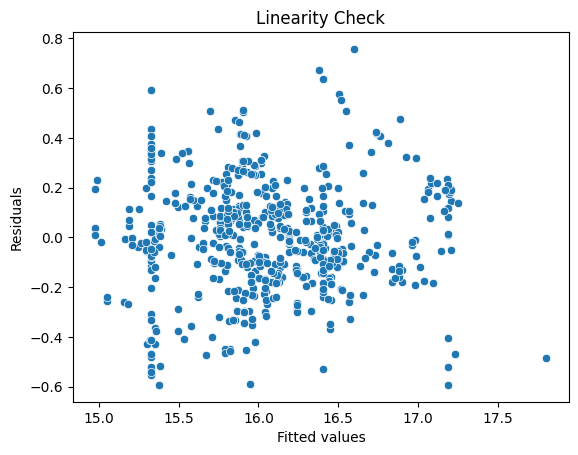

In [216]:
def linearity_test(model):
    """Perform the RESET test for linearity

    Args:
        model (statsmodels regression results): The fitted regression model
    Returns:
        reset_test_results: The RESET test results
    """
    reset_test_results = linear_reset(model, power=2, use_f = True) # RESET test
    print(f"F-stat: {reset_test_results.fvalue:.3f}, p-value: {reset_test_results.pvalue:.4f}")

    ### Store y_pred, and residuals to plot the scatterplot
    y_pred = final_model.fittedvalues
    residuals = final_model.resid

    sns.scatterplot(x=y_pred, y=residuals);
    plt.title("Linearity Check")
    plt.xlabel("Fitted values")
    plt.ylabel("Residuals");

linearity_test(final_model)

#### Fit the final model

In [217]:
sklearn_model = LinearRegression().fit(X_train, y_train)
sklearn_model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### Model metrics

Final model metrics:
MAE     0.177827
RMSE    0.229444
Name: Metrics, dtype: float64
Cross validation score of the seen data:
[0.8410836  0.77010634 0.81146852 0.84160441 0.83634615]


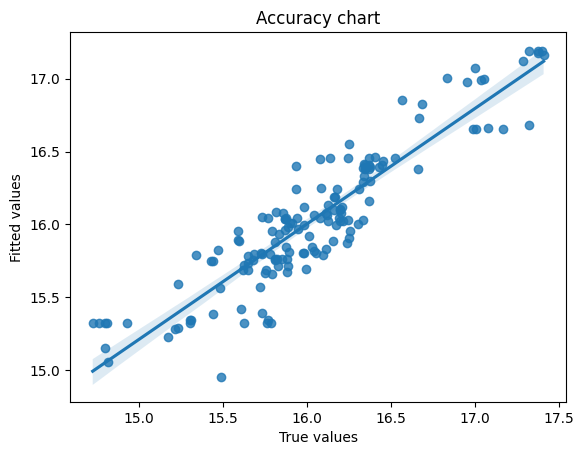

In [218]:
def model_performance(y_pred, y_test, X_train, y_train, estimator):
    """Shows the MAE, RMSE, Accuracy Chart(fitted, True), and cross validation scores(cv=5)

    Args:
        y_pred (array_like): The fitted values 
        y_test (array_like): The true values
        estimator (Model): The fitted model
    """

    mae = mean_absolute_error(y_test, y_pred) # MAE value
    rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # RMSE value
    # metics series
    metrics = pd.Series({
        "MAE": mae,
        "RMSE": rmse,
    }, name="Metrics")

    # plot the y_true vs. y_pred
    sns.regplot(x=y_test, y=y_pred)
    plt.title("Accuracy chart")
    plt.xlabel("True values")
    plt.ylabel("Fitted values")

    print(f"Final model metrics:\n{metrics}")
    cross_val_scores = cross_val_score(estimator, X_train, y_train, cv=5) # cross validation scores of the seen data
    print(f"Cross validation score of the seen data:\n{cross_val_scores}")
y_pred = sklearn_model.predict(X_test)
model_performance(y_pred, y_test, X_train, y_train, sklearn_model)

MAE, RMSE are close, Stable model

> Our model is stable across different samples

#### Experimental with multiple models

Decision Tree Performance:
Final model metrics:
MAE     0.140154
RMSE    0.239652
Name: Metrics, dtype: float64
Cross validation score of the seen data:
[0.84331782 0.62183364 0.79187491 0.77303544 0.78593319]


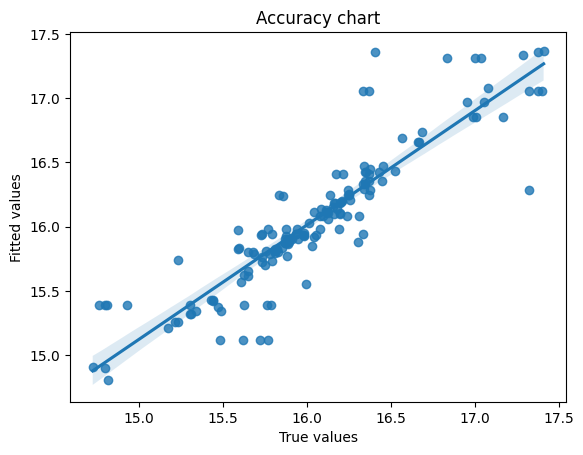

In [219]:
def decision_tree(X_train,X_test, y_test):
    """Perform a decision tree for comparing

    Args:
        X_train (array_like): the seen x data
        X_test (array_like): the unseen x data
        y_test (array_like): the actual y data
    Returns:
        Decision Tree model: The final fitted model
    """

    # Decision Tree
    dt_model = DecisionTreeRegressor(random_state=42)

    dt_model.fit(X_train, y_train)

    dt_predictions = dt_model.predict(X_test)

    print("Decision Tree Performance:")
    model_performance(dt_predictions, y_test, X_train, y_train, dt_model)
    
    return dt_model
dt_model = decision_tree(X_train,X_test, y_test)

Low MAE, and RMSE, slightly stable. This model have the lowest errors in the middle of the chart


Random Forest Performance:
Final model metrics:
MAE     0.130727
RMSE    0.195937
Name: Metrics, dtype: float64
Cross validation score of the seen data:
[0.89363461 0.75688435 0.83491236 0.83036453 0.85111286]


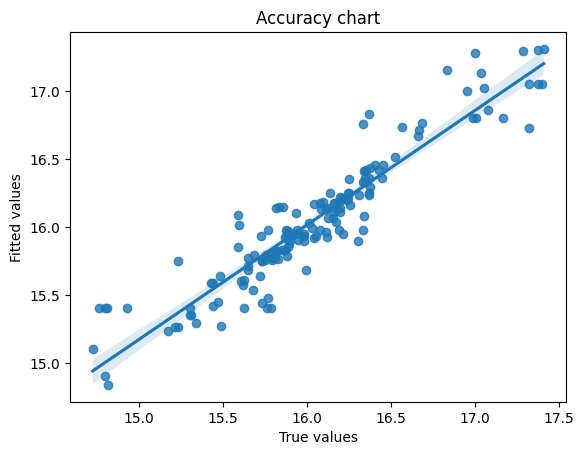

In [220]:
def random_forest(X_train, X_test, y_test):
    """Perform a Random Forest for comparing

    Args:
        X_train (array_like): the seen x data
        X_test (array_like): the unseen x data
        y_test (array_like): the actual y data
    Returns:
        Random Forest model: The final fitted model
    """
    # Random Forest
    rf_model = RandomForestRegressor(random_state=42)
    rf_model.fit(X_train, y_train)
    rf_predictions = rf_model.predict(X_test)
    print("\nRandom Forest Performance:")
    model_performance(rf_predictions, y_test, X_train, y_train, rf_model)
    return rf_model

rf_model = random_forest(X_train, X_test, y_test)

- RandomForest model is slightly stable model with lower errors in the middle of the chart, and the higher errors on the sides of the chart(right, and left). Overall the model is  great

- DecisionTree model is a unstable model with the same shape of the RandomForest. Overall the model is good

- LinearRegression model is a Stable mode, low variance. Overall the model is very good


> The best one is Linear regression model, due to it have the lowest MAE, RMSE, and the most stable model

### Outliers regression

#### Set x,y

In [221]:
x,y = set_xy(reg_df, "log(price)", True, outliers_list, drop_cols) # set x, y


X_train, X_test, y_train, y_test = split_data(x,y, 0.081) # split the data into train, and test data(test_data = 10 rows)

reg_summary(X_train, y_train) # Show the model summary

The regression model summary:
                                  Results: Ordinary least squares
Model:                           OLS                         Adj. R-squared:                0.984   
Dependent Variable:              log(price)                  AIC:                           -83.8254
Date:                            2025-11-05 13:45            BIC:                           -23.3544
No. Observations:                83                          Log-Likelihood:                66.913  
Df Model:                        24                          F-statistic:                   215.2   
Df Residuals:                    58                          Prob (F-statistic):            4.30e-48
R-squared:                       0.989                       Scale:                         0.016709
----------------------------------------------------------------------------------------------------
                                                      Coef.  Std.Err.    t    P>|t|   [0.025  0.

> We have high multicollinearity. The shape of the residuals isn't a normal distribution, with high skewness, with leptokurtic shape. JB p-value = 0.0 shows the non-normality of the residuals.

#### Model selection

- Add some interactions

In [222]:
outliers_df = x.join(y)

# interactions
outliers_df["(log(sqm)_centered)**3"] = outliers_df["log(sqm)_centered"] ** 3

outliers_df["has_modern * has_green_view"] = outliers_df["has_modern"] * outliers_df["has_green_view"]

# Set x,y
x,y = set_xy(outliers_df, "log(price)", True, outliers_list, drop_cols) # set x, y

# split the data 
X_train, X_test, y_train, y_test = split_data(x,y, 0.081) # split the data into train, and test data(test_data = 10 rows)

# drop the constant features
constant_features = X_train.nunique()[X_train.nunique() == 1].index
X_train.drop(constant_features, axis=1, inplace=True) # drop constant columns
X_test.drop(constant_features, axis=1, inplace=True) # drop constant columns

# make the train data
train_df = X_train.join(y_train) # The joint data
outliers_model, removed_vars, _ = general_to_specific(train_df, "log(price)", X_train.columns) # Perform the model selection

X_train.drop(removed_vars, axis = 1, inplace=True) # drop the removed variables from X_train
X_test.drop(removed_vars, errors="ignore", axis =1, inplace=True) # drop the removed variables from X_test

Removing HighFloor due to corrected p=0.9675
Removing HighFloor * has_green_view due to corrected p=0.9524
Removing Bathroom_2 due to corrected p=0.8872
Removing log(sqm)_centered due to corrected p=0.6155
Removing has_modern due to corrected p=0.7208
Removing MidFloor due to corrected p=0.5983
Removing city_New Cairo due to corrected p=0.5368
Removing has_modern * has_green_view due to corrected p=0.2771
Removing city_Mansoura due to corrected p=0.4102
Removing (log(sqm)_centered)**3 due to corrected p=0.2038
Removing propertySubType_Office due to corrected p=0.5286
Removing propertySubType_Others(very rare) due to corrected p=0.8325
Removing city_New Administrative Capital due to corrected p=0.5062
Removing has_water_feature due to corrected p=0.4280
Removing has_water_feature * has_green_view due to corrected p=0.4280
Removing city_North Coast due to corrected p=0.3427
Removing Bathroom_above 2 due to corrected p=0.2889
Removing propertyCategory_Commercial * log(sqm) centered ** 2 d

- The model is good, normal residuals distribution, no autocorrelation

#### RESET Test

F-stat: 1.387, p-value: 0.2428


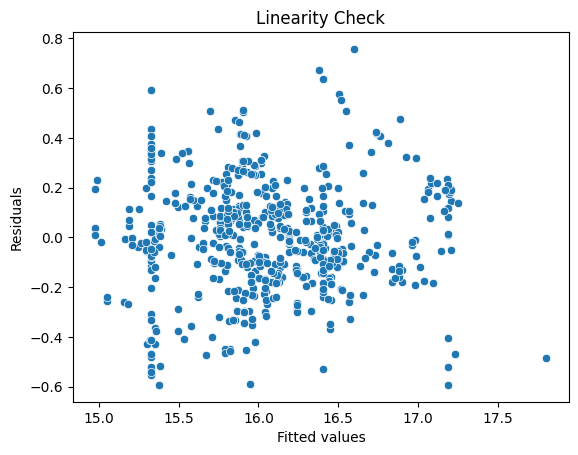

In [223]:
linearity_test(outliers_model)

- Fail to reject the linearity assumption

Final model metrics:
MAE     0.102118
RMSE    0.137124
Name: Metrics, dtype: float64
Cross validation score of the seen data:
[0.96949376 0.96971697 0.97170365 0.89044798 0.82325714]


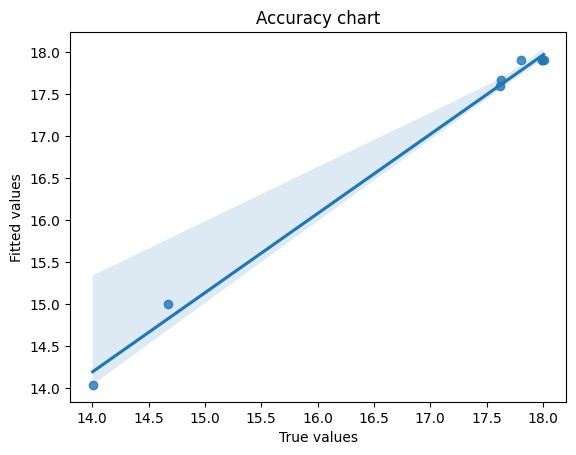

In [224]:
outliers_model_sklearn = LinearRegression().fit(X_train, y_train) # outliers sklearn model

y_pred = outliers_model_sklearn.predict(X_test) # store the fitted y(10 rows)

model_performance(y_pred, y_test, X_train, y_train, outliers_model_sklearn) # Show the model performance using test data(10 rows)

- The model performance is slightly stable for outliers real estates(Extreme, prices, and sqm), low MAE, and RMSE, low error which shown in the chart

#### Random forest, and decision tree models

##### Decision tree model

Decision Tree Performance:
Final model metrics:
MAE     0.474554
RMSE    1.000427
Name: Metrics, dtype: float64
Cross validation score of the seen data:
[0.94293537 0.97884141 0.95309604 0.86052988 0.34045032]


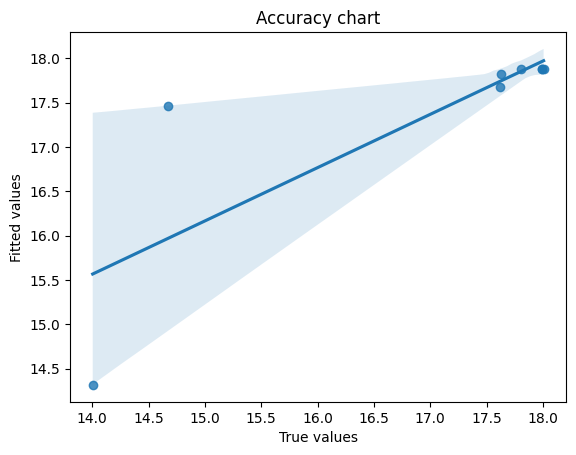

In [225]:
outliers_dt_model = decision_tree(X_train, X_test, y_test) # decision tree model of outliers data

- The model performance is unstable, low MAE, and RMSE. low Errors which also show in the chart, but we have two values have very high errors

##### Random forest model


Random Forest Performance:
Final model metrics:
MAE     0.521115
RMSE    1.027902
Name: Metrics, dtype: float64
Cross validation score of the seen data:
[0.94859708 0.98372663 0.9554501  0.80283585 0.4511672 ]


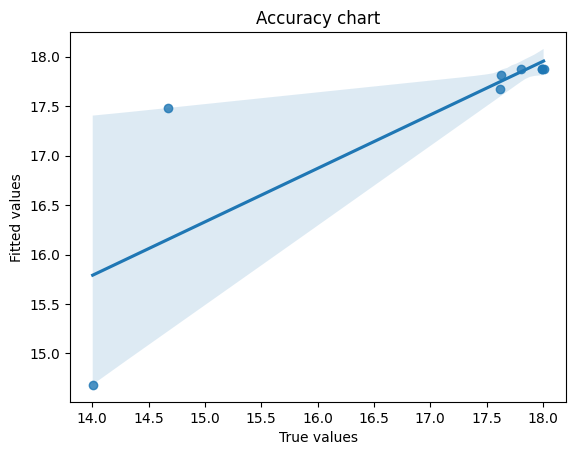

In [226]:
rf_outliers_model = random_forest(X_train, X_test, y_test) # Random forest model of outliers data

- The model performance is unstable

#### summary:

The final best model is the Linear regression model due to stability, and low MAE, RMSE in outliers models

## Summary:

- The best model in outliers is Linear Regression, and non_outliers is Linear regression model
- The number of features of outliers model is less than the outliers model due to high Vifs, and p-values
- The non-outliers models shows a stable performance, good MAE, RMSE, but outliers models shows a slightly stable models, good MAE, RMSE due to the shocks in the data
- The non-outliers model explained $\approx$ 80% of the data, but the outliers model explained $\approx$ 96% of the data due to the small number of observation compared to the non-outliers number of observations 
- Performed model specification, and model selection using GETS method
- Performed model evaluation to compare different models to get the best AIC, $R^2$, and stability